In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data_path = '/content/drive/MyDrive/data/'

In [4]:
import pandas as pd

customers = pd.read_csv(data_path + 'customers - customers.csv')
orders = pd.read_csv(data_path + 'orders - orders.csv')
order_items = pd.read_csv(data_path + 'order_items - order_items.csv')
products = pd.read_csv(data_path + 'products - products.csv')
payments = pd.read_csv(data_path + 'payments - payments.csv')

In [5]:
print(customers.shape)
print(orders.shape)

(99441, 5)
(99441, 8)


In [6]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

In [7]:
orders['year'] = orders['order_purchase_timestamp'].dt.year
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')

In [8]:
df = orders.merge(order_items, on='order_id')
df = df.merge(products, on='product_id')

In [18]:
def clean_columns(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
        .str.replace('-', '_')
    )
    return df

customers = clean_columns(customers)
orders = clean_columns(orders)
order_items = clean_columns(order_items)
products = clean_columns(products)
payments = clean_columns(payments)

In [19]:
df = orders.merge(order_items, on='order_id')
df = df.merge(products, on='product_id')

In [20]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'year', 'month', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'product_category',
       'product_name_length', 'product_description_length',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm'],
      dtype='object')

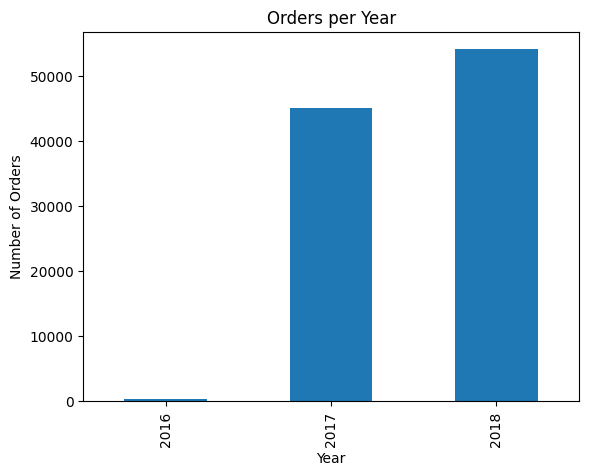

In [9]:
yearly_orders = orders.groupby('year').size()

yearly_orders.plot(kind='bar')
plt.title('Orders per Year')
plt.xlabel('Year')
plt.ylabel('Number of Orders')
plt.show()

Orders show a growth trend over the years, highest in 2018 then the previous year.


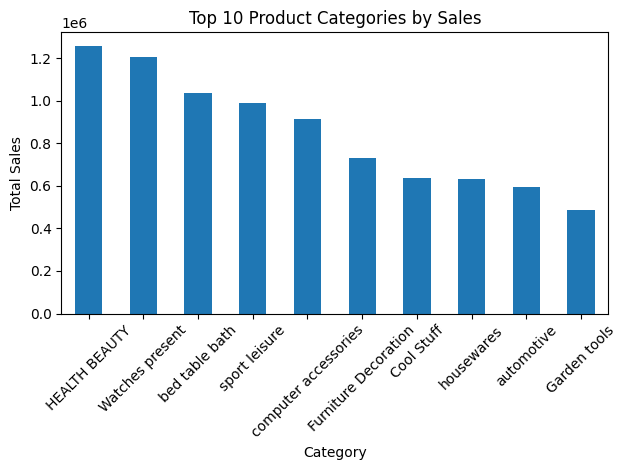

In [21]:
category_sales = (
    df.groupby('product_category')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

category_sales.plot(kind='bar')
plt.title('Top 10 Product Categories by Sales')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

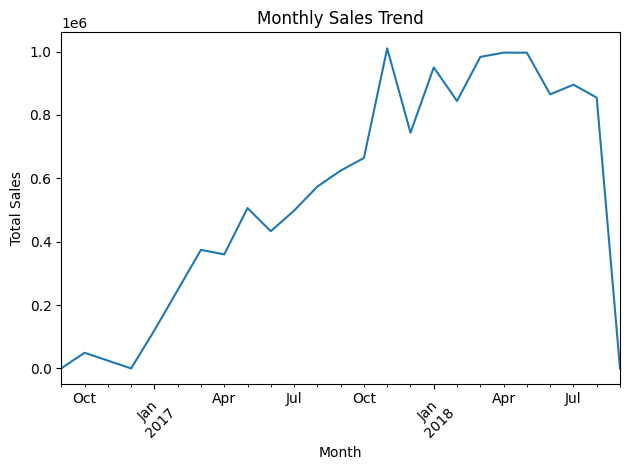

In [22]:
monthly_sales = (
    df.groupby('month')['price']
    .sum()
    .sort_index()
)

plt.figure()
monthly_sales.plot()
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sales show seasonal fluctuations with visible peaks, indicating demand variation across months, peaked in month of april and growth is significantly seen till April 2018 but after that the declining in the sales start.


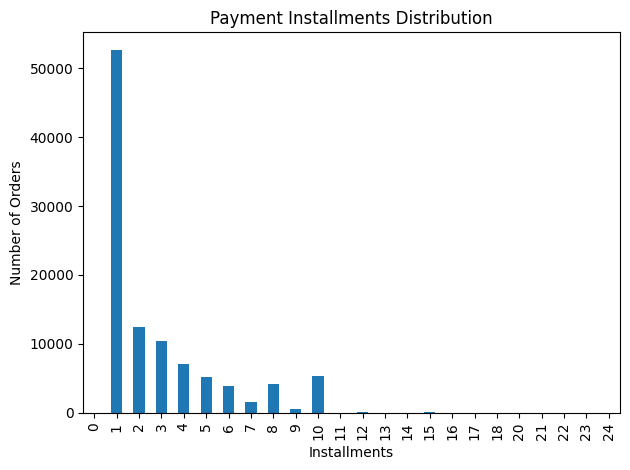

In [24]:
payments['payment_installments'].value_counts().sort_index().plot(kind='bar')

plt.title('Payment Installments Distribution')
plt.xlabel('Installments')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

Customers prefer lower installment counts, indicating short-term payment flexibility is more popular.


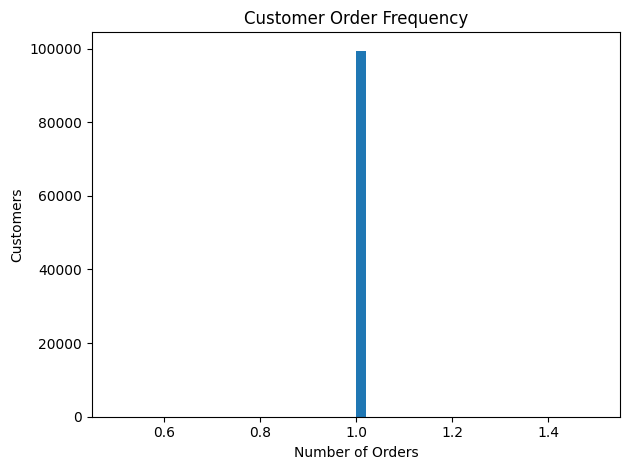

In [25]:
customer_orders = orders.groupby('customer_id').size()

plt.figure()
customer_orders.plot(kind='hist', bins=50)

plt.title('Customer Order Frequency')
plt.xlabel('Number of Orders')
plt.ylabel('Customers')
plt.tight_layout()
plt.show()

Most customers are one-time buyers, indicating low retention and potential for improvement in repeat purchases.

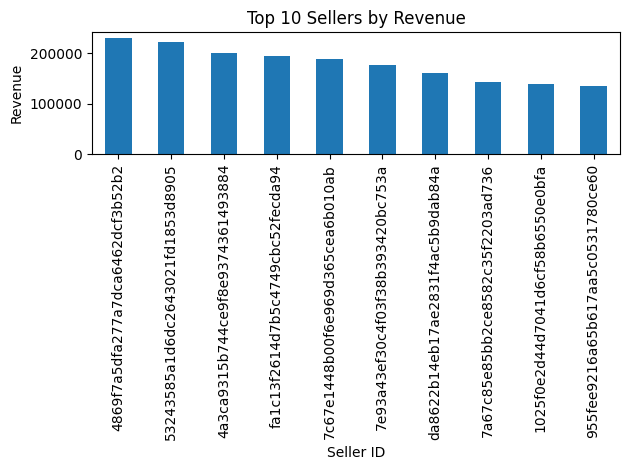

In [26]:
seller_df = order_items.merge(orders, on='order_id')

top_sellers = (
    seller_df.groupby('seller_id')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_sellers.plot(kind='bar')

plt.title('Top 10 Sellers by Revenue')
plt.xlabel('Seller ID')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

A small group of sellers contributes a large portion of revenue, indicating a skewed seller performance distribution.”

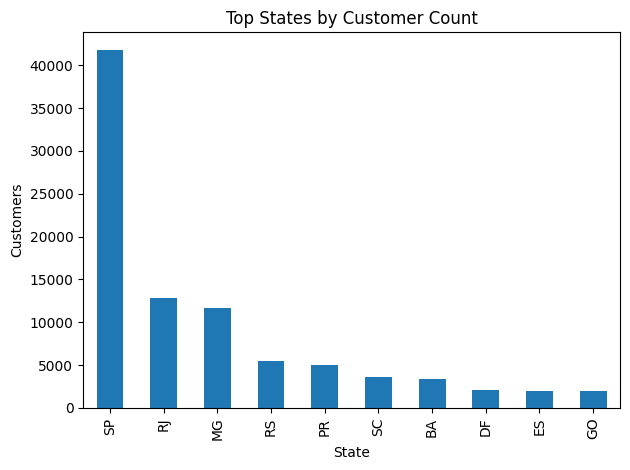

In [27]:
customers['customer_state'].value_counts().head(10).plot(kind='bar')

plt.title('Top States by Customer Count')
plt.xlabel('State')
plt.ylabel('Customers')
plt.tight_layout()
plt.show()

Customer base is concentrated in a few states, indicating regional demand clusters.

In [28]:
seller_revenue = order_items.groupby('seller_id')['price'].sum()

seller_revenue.describe()

,price
count,3095.000000
mean,4391.484233
std,13921.997192
min,3.500000
25%,208.850000
50%,821.480000
75%,3280.830000
max,229472.630000


Seller revenue is highly skewed, with a small percentage of sellers contributing the majority of total sales, indicating platform dependency on top performers

##  Key Insights (Numerical Summary)

- Total Orders: ~99,000+
- Orders in 2017: 45,101
- Percentage of Orders in Installments: 49.42%
- Top Category Contribution: Highest revenue driven by top 10 categories
- Customer Behavior: Majority customers are one-time buyers
- Seller Contribution: Top sellers contribute a significant portion of revenue

##  Business Insights

- Nearly **49.42% of orders** are paid via installments, indicating strong preference for flexible payment options.
- Around **45,101 orders were placed in 2017**, showing significant platform activity during that year.
- A small number of product categories contribute the majority of revenue, highlighting key business drivers.
- Customer purchasing behavior is skewed toward **single-order customers**, indicating low retention.
- Seller performance is uneven, with **top sellers generating disproportionately high revenue**.

##  Conclusion

The analysis reveals that the e-commerce platform demonstrates steady growth with strong order volumes and revenue concentration in key product categories. Customer behavior indicates a high reliance on installment-based payments and a tendency toward one-time purchases.

Additionally, seller performance is highly skewed, suggesting dependency on a limited number of high-performing sellers. Overall, while the platform shows strong transactional activity, there is significant opportunity to improve customer retention and diversify revenue sources.

##  Recommendations

- Enhance customer retention strategies through loyalty programs and personalized offers to convert one-time buyers into repeat customers.
- Promote installment payment options further, as nearly half of the customers prefer this method.
- Support and onboard more sellers to reduce dependency on top-performing sellers.
- Focus marketing efforts on high-performing product categories to maximize revenue.
- Identify underperforming regions and improve logistics or marketing strategies to expand customer base.

##  Future Scope

- Implement customer segmentation for targeted marketing
- Perform cohort analysis for deeper retention insights
- Build predictive models for sales forecasting